### **Import Library**

In [124]:
pip install Sastrawi

In [125]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import joblib

from wordcloud import WordCloud
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.StopWordRemover.StopWordRemover import StopWordRemover
from Sastrawi.Dictionary.ArrayDictionary import ArrayDictionary
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from google.colab import drive

### **Load Dataset**

In [126]:
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/data_fix.csv'
df_ig     = pd.read_csv(file_path)
df_ig.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Id,Sentiment,Instagram Comment Text
0,1,negative,<USERNAME> TOLOL!! Gak ada hubungan nya kegug...
1,2,negative,Geblek lo tata...cowo bgt dibela2in balikan......
2,3,negative,Kmrn termewek2 skr lengket lg duhhh kok labil ...
3,4,negative,"Intinya kalau kesel dengan ATT nya, gausah ke ..."
4,5,negative,"hadewwwww permpuan itu lg!!!!sakit jiwa,knp ha..."


In [127]:
df_ig.rename(columns={'Instagram Comment Text': 'comment', 'Sentiment': 'sentiment'}, inplace=True)
df_ig = df_ig.drop(columns=['Id'], axis=1)
df_ig.drop_duplicates(inplace=True)
df_ig.dropna(inplace=True)
df_ig.head()

,sentiment,comment
0,negative,<USERNAME> TOLOL!! Gak ada hubungan nya kegug...
1,negative,Geblek lo tata...cowo bgt dibela2in balikan......
2,negative,Kmrn termewek2 skr lengket lg duhhh kok labil ...
3,negative,"Intinya kalau kesel dengan ATT nya, gausah ke ..."
4,negative,"hadewwwww permpuan itu lg!!!!sakit jiwa,knp ha..."


### **Data Preprocessing**

#### 01: Data Cleaning

01.1: Emoticon Replacement

In [128]:
# def remove_emoji(text):
#     if isinstance(text, str):
#         emoji_pattern = re.compile("["
#                            u"\U0001F600-\U0001F64F"  # emoticons
#                            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
#                            u"\U0001F680-\U0001F6FF"  # transport & map symbols
#                            u"\U0001F700-\U0001F77F"  # alchemical symbols
#                            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
#                            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
#                            u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
#                            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
#                            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
#                            u"\U00002702-\U000027B0"  # Dingbats
#                            u"\U000024C2-\U0001F251"
#                            "]+", flags=re.UNICODE)
#         return emoji_pattern.sub(r'', text)
#     else:
#         return text

emoji_dict = {
    "❤️": "cinta", "🧡": "cinta", "💛": "cinta", "💚": "cinta",
    "💙": "cinta", "💜": "cinta", "🖤": "cinta", "🤍": "cinta",
    "🤎": "cinta", "💖": "cinta", "💗": "cinta", "💘": "cinta",
    "💝": "cinta", "💞": "cinta", "💕": "cinta", "💓": "cinta",
    "💟": "cinta", "❣️": "cinta", "♥️": "cinta",
    "😍": "cinta", "🥰": "cinta", "😘": "cinta", "😗": "cinta",
    "😙": "cinta", "😚": "cinta", "💋": "cinta",
    "🫶": "cinta", "🫶🏻": "cinta", "🫶🏼": "cinta", "🫶🏽": "cinta",
    "🫶🏾": "cinta", "🫶🏿": "cinta", "😻": "cinta", "👍": "bagus",

    "😂": "lucu",   "🤣": "lucu",   "😹": "lucu",
    "😄": "senang", "😃": "senang", "😀": "senang",
    "😁": "senang", "😆": "senang", "😊": "senang",
    "🙂": "senang", "☺️": "senang", "😇": "senang",
    "🥳": "senang", "😸": "senang",

    "😢": "sedih", "😭": "sedih", "😿": "sedih",
    "😞": "sedih", "😔": "sedih", "☹️": "sedih",
    "🙁": "sedih", "😟": "sedih", "🥺": "sedih",
    "💔": "kecewa",

    "😡": "marah", "😠": "marah", "🤬": "marah",
    "😤": "marah", "👿": "marah",

    "😱": "kaget", "😨": "takut", "😰": "takut",
    "😥": "takut", "😓": "takut",

    "😐": "netral", "😑": "netral", "😶": "diam",
    "🤔": "bingung", "😕": "bingung", "😵": "bingung",

    "👍": "bagus", "👍🏻": "bagus", "👍🏼": "bagus",
    "👍🏽": "bagus", "👍🏾": "bagus", "👍🏿": "bagus",
    "👌": "bagus", "👏": "bagus", "🙌": "bagus",
    "💪": "semangat", "🔥": "keren", "✨": "keren",

    "👎": "buruk", "👎🏻": "buruk", "👎🏼": "buruk",
    "👎🏽": "buruk", "👎🏾": "buruk", "👎🏿": "buruk",

    "🤢": "jijik", "🤮": "jijik",

    "😴": "ngantuk", "🥱": "ngantuk", "😪": "ngantuk",

    "🙏": "terima_kasih", "🙏🏻": "terima_kasih",
    "🙏🏼": "terima_kasih", "🙏🏽": "terima_kasih",
    "🙏🏾": "terima_kasih", "🙏🏿": "terima_kasih"
}

def emoji_to_indonesian(text):
    if isinstance(text, str):
        for emo, arti in emoji_dict.items():
            text = text.replace(emo, f" {arti} ")
        return text
    return text

In [129]:
df_ig['comment'] = df_ig['comment'].apply(emoji_to_indonesian)
df_ig.head()

,sentiment,comment
0,negative,<USERNAME> TOLOL!! Gak ada hubungan nya kegug...
1,negative,Geblek lo tata...cowo bgt dibela2in balikan......
2,negative,Kmrn termewek2 skr lengket lg duhhh kok labil ...
3,negative,"Intinya kalau kesel dengan ATT nya, gausah ke ..."
4,negative,"hadewwwww permpuan itu lg!!!!sakit jiwa,knp ha..."


01.2: Text Replacement

In [130]:
def clean_text(text):
  text = re.sub(r'@[\w]+', 'username', text) # mention / username
  text = re.sub(r'<[^>]+>', '', text) # tag html
  text = re.sub(r'[^\w\s]', '', text) # tanda baca
  text = re.sub(r'\d+', '', text) # angka
  text = re.sub(r'\s+', ' ', text).strip() # spasi ganda ke tunggal
  text = re.sub(r'(.)\1{2,}', r'\1', text) # huruf berulang
  text = ' '.join([w for w in text.split() if 2 <= len(w) <= 15]) # karakter panjang
  text = re.sub(r'[^\x00-\x7F]+', ' ', text) # non ASCII

  return text.lower()

In [131]:
df_ig['cleaned_comment'] = df_ig['comment'].apply(clean_text)
df_ig.head()

,sentiment,comment,cleaned_comment
0,negative,<USERNAME> TOLOL!! Gak ada hubungan nya kegug...,tolol gak ada hubungan nya keguguran dgn pake ...
1,negative,Geblek lo tata...cowo bgt dibela2in balikan......,geblek lo tatacowo bgt dibelain ditinggal lg n...
2,negative,Kmrn termewek2 skr lengket lg duhhh kok labil ...,kmrn termewek skr lengket lg duh kok labil bgt...
3,negative,"Intinya kalau kesel dengan ATT nya, gausah ke ...",intinya kalau kesel dengan att nya gausah ke a...
4,negative,"hadewwwww permpuan itu lg!!!!sakit jiwa,knp ha...",hadew permpuan itu lgsakit jiwaknp harus dia y...


01.3: Slang Words Normalization

In [132]:
slang_dict = {
    'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak',
    'lo': 'kamu', 'gw': 'saya', 'aja': 'saja',
    'bgt': 'banget', 'skr': 'sekarang', 'lg': 'lagi',
    'dll': 'dan lain-lain', 'sm': 'sama', 'cakeupp': 'cakep',

    'klo': 'kalau', 'kalo': 'kalau',
    'tp': 'tapi', 'tpi': 'tapi',
    'bkn': 'bukan',
    'udh': 'sudah', 'udah': 'sudah',
    'jd': 'jadi', 'jdi': 'jadi',
    'sdh': 'sudah',
    'dgn': 'dengan',
    'knp': 'kenapa',
    'msh': 'masih',
    'tau': 'tahu',
    'tdk': 'tidak',
    'gk': 'tidak',
    'hrs': 'harus',

    'lu': 'kamu', 'elu': 'kamu',
    'gue': 'saya', 'ane': 'saya',
    'nyah': 'nya', 'deseu': 'dia',
    'seseorang': 'orang',
    'ertong': 'artis',
    'min': 'admin', 'mimin': 'admin',

    'emg': 'emang', 'memang': 'memang', 'org': 'orang',
    'bener': 'benar',
    'skali': 'sekali', 'skr': 'sekarang',
    'bangettt': 'banget',
    'pake': 'pakai',
    'pakek': 'pakai',
    'liat': 'lihat',
    'liatnya': 'lihatnya',
    'aj': 'saja', 'ajah': 'saja', 'kmrn': 'kemarin',
    'kayakgni': 'seperti ini', 'belajaer': 'belajar',
    'permpuan': 'perempuan',

    'goblok': 'bodoh', 'goblog': 'bodoh',
    'bego': 'bodoh',
    'tolol': 'bodoh', 'geblek': 'bodoh'
}

In [133]:
def normalize_text(text):
    return ' '.join([slang_dict.get(word, word) for word in text.split()])

df_ig['normalized_comment'] = df_ig['cleaned_comment'].apply(normalize_text)
df_ig.head()

,sentiment,comment,cleaned_comment,normalized_comment
0,negative,<USERNAME> TOLOL!! Gak ada hubungan nya kegug...,tolol gak ada hubungan nya keguguran dgn pake ...,bodoh tidak ada hubungan nya keguguran dengan ...
1,negative,Geblek lo tata...cowo bgt dibela2in balikan......,geblek lo tatacowo bgt dibelain ditinggal lg n...,bodoh kamu tatacowo banget dibelain ditinggal ...
2,negative,Kmrn termewek2 skr lengket lg duhhh kok labil ...,kmrn termewek skr lengket lg duh kok labil bgt...,kemarin termewek sekarang lengket lagi duh kok...
3,negative,"Intinya kalau kesel dengan ATT nya, gausah ke ...",intinya kalau kesel dengan att nya gausah ke a...,intinya kalau kesel dengan att nya gausah ke a...
4,negative,"hadewwwww permpuan itu lg!!!!sakit jiwa,knp ha...",hadew permpuan itu lgsakit jiwaknp harus dia y...,hadew perempuan itu lgsakit jiwaknp harus dia ...


01.4: Drop Unimportant Columns

In [134]:
df_ig = df_ig.drop(columns=['comment', 'cleaned_comment'])
df_ig.head()

,sentiment,normalized_comment
0,negative,bodoh tidak ada hubungan nya keguguran dengan ...
1,negative,bodoh kamu tatacowo banget dibelain ditinggal ...
2,negative,kemarin termewek sekarang lengket lagi duh kok...
3,negative,intinya kalau kesel dengan att nya gausah ke a...
4,negative,hadew perempuan itu lgsakit jiwaknp harus dia ...


#### **02: Stop Word Remover**

In [135]:
factory_stopword = StopWordRemoverFactory()
stopword         = factory_stopword.get_stop_words()

if 'tidak' in stopword:
  stopword.remove('tidak')
if 'bukan' in stopword:
  stopword.remove('bukan')

dictionary       = ArrayDictionary(stopword)
stopword_remover = StopWordRemover(dictionary)

def remove_stopword(text):
  if isinstance(text, str):
    return stopword_remover.remove(text)
  return text

In [136]:
df_ig['remove_stopword'] = df_ig['normalized_comment'].apply(remove_stopword)
df_ig.head(n=3)

,sentiment,normalized_comment,remove_stopword
0,negative,bodoh tidak ada hubungan nya keguguran dengan ...,bodoh tidak hubungan nya keguguran pakai hijab...
1,negative,bodoh kamu tatacowo banget dibelain ditinggal ...,bodoh kamu tatacowo banget dibelain ditinggal ...
2,negative,kemarin termewek sekarang lengket lagi duh kok...,kemarin termewek sekarang lengket duh kok labi...


#### **03: Stemming**

In [137]:
factory_stemmer = StemmerFactory()
stemmer         = factory_stemmer.create_stemmer()

def stemmer_text (text):
  if isinstance(text, str):
    return stemmer.stem(text)
  return text

In [138]:
df_ig['stemmed_comment'] = df_ig['remove_stopword'].apply(stemmer_text)
df_ig.head()

,sentiment,normalized_comment,remove_stopword,stemmed_comment
0,negative,bodoh tidak ada hubungan nya keguguran dengan ...,bodoh tidak hubungan nya keguguran pakai hijab...,bodoh tidak hubung nya gugur pakai hijab syar ...
1,negative,bodoh kamu tatacowo banget dibelain ditinggal ...,bodoh kamu tatacowo banget dibelain ditinggal ...,bodoh kamu tatacowo banget bain tinggal nyalah...
2,negative,kemarin termewek sekarang lengket lagi duh kok...,kemarin termewek sekarang lengket duh kok labi...,kemarin mewek sekarang lengket duh kok labil b...
3,negative,intinya kalau kesel dengan att nya gausah ke a...,intinya kalau kesel att nya gausah anaknya kas...,inti kalau kesel att nya gausah anak kasi buat...
4,negative,hadew perempuan itu lgsakit jiwaknp harus dia ...,hadew perempuan lgsakit jiwaknp dia jadi peran...,hadew perempuan lgsakit jiwaknp dia jadi peran...


### **Post-Preprocessing**

#### **01: Split Dataset**

In [139]:
X = df_ig['stemmed_comment']
y = df_ig['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [140]:
print(f'{X_train.shape}, {X_test.shape}')

(676,), (170,)


#### **02: Feature Extraction**

In [141]:
vectorizer    = TfidfVectorizer()
X_tr_vector   = vectorizer.fit_transform(X_train)
X_test_vector = vectorizer.transform(X_test)

In [142]:
df_tfid = pd.DataFrame(X_tr_vector.toarray(), columns=vectorizer.get_feature_names_out())
df_tfid.tail()

,abal,abang,abege,abis,abu,acara,ada,adalah,adaptasi,adem,...,yaudah,ye,yng,yoo,you,youtube,yutub,zaman,zholimi,zonasi
671,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
672,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
673,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
674,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
675,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### **03: Visualization**

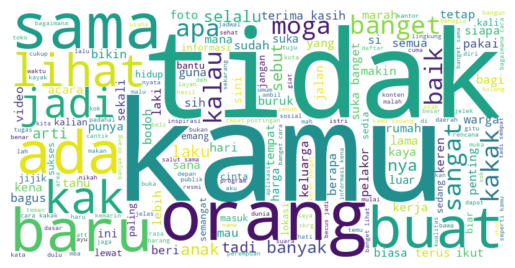

In [143]:
text = " ".join(X)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### **Modeling**

#### **01: Inisialisasi Model**

In [144]:
nb_model  = MultinomialNB()
svm_model = SVC(kernel='linear')

#### **02: Training Model**

In [145]:
nb_model.fit(X_tr_vector, y_train)
svm_model.fit(X_tr_vector, y_train)

SVC(kernel='linear')

#### **03: Testing Model**

In [146]:
nb_tr_pred = nb_model.predict(X_tr_vector)
svm_tr_pred = svm_model.predict(X_tr_vector)

In [147]:
nb_pred  = nb_model.predict(X_test_vector)
svm_pred = svm_model.predict(X_test_vector)

#### **04: Classification Report**

04.1: Naive Bayes Report (Train & Test)

In [148]:
print(classification_report(y_train, nb_tr_pred))

              precision    recall  f1-score   support

    negative       1.00      0.97      0.99       156
     neutral       0.98      1.00      0.99       320
    positive       1.00      0.99      1.00       200

    accuracy                           0.99       676
   macro avg       0.99      0.99      0.99       676
weighted avg       0.99      0.99      0.99       676



In [149]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

    negative       1.00      0.85      0.92        40
     neutral       0.90      1.00      0.95        80
    positive       0.98      0.92      0.95        50

    accuracy                           0.94       170
   macro avg       0.96      0.92      0.94       170
weighted avg       0.95      0.94      0.94       170



04.2: SVM Report (Train & Test)

In [150]:
print(classification_report(y_train, svm_tr_pred))

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       156
     neutral       1.00      1.00      1.00       320
    positive       1.00      1.00      1.00       200

    accuracy                           1.00       676
   macro avg       1.00      1.00      1.00       676
weighted avg       1.00      1.00      1.00       676



In [151]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

    negative       1.00      0.97      0.99        40
     neutral       0.98      1.00      0.99        80
    positive       0.98      0.96      0.97        50

    accuracy                           0.98       170
   macro avg       0.99      0.98      0.98       170
weighted avg       0.98      0.98      0.98       170



### **External Data**

In [152]:
def preprocessing(text):
  text = emoji_to_indonesian(text)
  text = clean_text(text)
  text = normalize_text(text)

  text = remove_stopword(text)
  text = stemmer_text(text)
  vector = vectorizer.transform([text])
  return vector

def predict_sentiment(text, model):
  vector = preprocessing(text)
  prediction = model.predict(vector)
  return prediction[0]

In [161]:
text = 'abay bulu²🫶'
print(predict_sentiment(text, nb_model))

positive


### **Download Model & Vectorizer**

In [154]:
joblib.dump(nb_model, 'nb_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

['vectorizer.pkl']